## Comparative analysis of results in Bologna:

### Mean Radiant Temperature predicted from High resolution data and open Global datasets

In [2]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import os

In [3]:
# inputs
mrt_predicted_hr_data = '../../datos-notebooks/1.HR-data-bologna/1.5.MRT-prediction/MRT_1m.tif'
mrt_predicted_global_data = '../../datos-notebooks/2.global-data-bologna/MRT-prediction/MRT_fromHR_1m.tif'
mrt_predicted_global_data_2 = '../../datos-notebooks/2.global-data-bologna/MRT-prediction/MRT_fromglobal_1m.tif'

#output
out_diff = '../../datos-notebooks/4.comparative-analysis/MRT_difference_bologna.tif'

### differences between predictions 

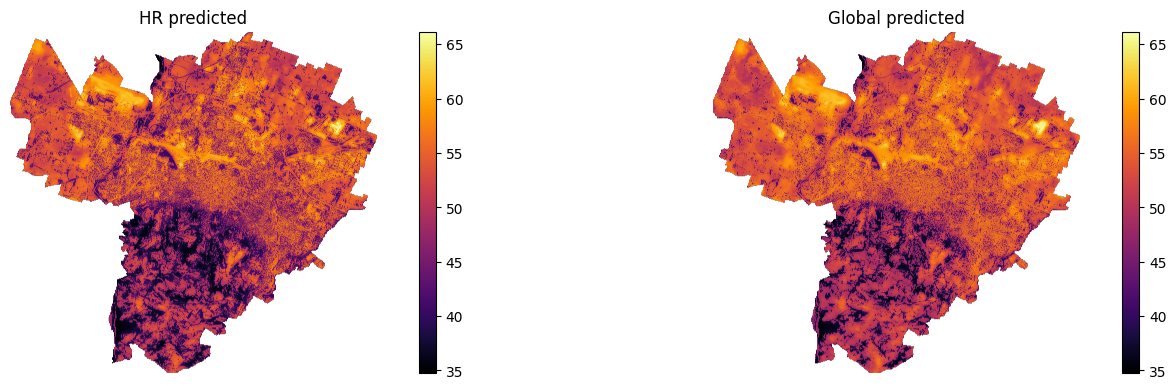

In [5]:
with  rasterio.open(mrt_predicted_hr_data) as hr, rasterio.open(mrt_predicted_global_data_2) as glob:
    xmin, ymin, xmax, ymax = hr.bounds
    hr_data = hr.read(1).astype("float32")  
    glob_data = glob.read(1).astype("float32")
    
fig, axes = plt.subplots(1, 2, figsize=(8, 4))



# HR predicted
im1 = axes[0].imshow(hr_data, cmap="inferno", vmin=np.nanmin(hr_data), vmax=np.nanmax(hr_data))
axes[0].set_title("HR predicted")
plt.colorbar(im1, ax=axes[0], fraction=0.046)

# Global predicted
im2 = axes[1].imshow(glob_data, cmap="inferno", vmin=np.nanmin(hr_data), vmax=np.nanmax(hr_data))
axes[1].set_title("Global predicted")
plt.colorbar(im2, ax=axes[1], fraction=0.046)



for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

#### model trained with HR data: applied with HR data and with global datasets

In [ ]:
os.makedirs(os.path.dirname(out_diff), exist_ok=True)

with rasterio.open(mrt_predicted_hr_data) as src1, \
     rasterio.open(mrt_predicted_global_data) as src2:

    # determine common intersection
    h = min(src1.height, src2.height)
    w = min(src1.width, src2.width)

    # read only that intersection (light)
    r1 = src1.read(1, window=((0, h), (0, w))).astype("float32")
    r2 = src2.read(1, window=((0, h), (0, w))).astype("float32")

    nodata = src1.nodata

    # build mask in HR intersection grid
    mask = np.isfinite(r1)
    if nodata is not None:
        mask &= (r1 != nodata)

    diff = r1 - r2
    diff[~mask] = nodata

    profile = src1.profile
    profile.update(dtype="float32", height=h, width=w, transform=src1.transform)

    with rasterio.open(out_diff, "w", **profile) as dst:
        dst.write(diff.astype("float32"), 1)

    print("Saved in:", out_diff)


Saved in: ../../datos-notebooks/4.comparative-analysis/MRT_difference_bologna.tif


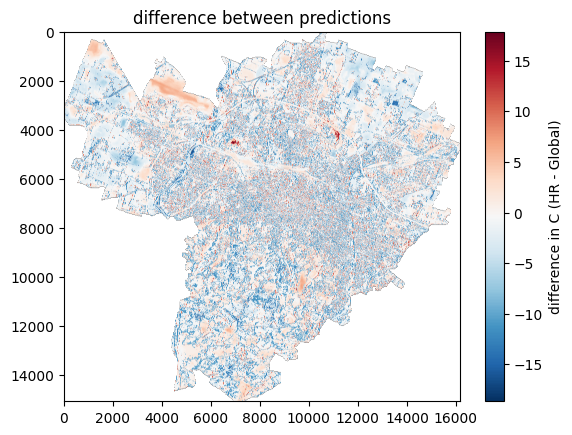

In [ ]:
# Plot result 
with rasterio.open(out_diff) as src:
    xmin, ymin, xmax, ymax = src.bounds

plt.figure()
plt.title("difference between predictions")
plt.imshow(diff, cmap='RdBu_r')
plt.colorbar(label="difference in C (HR - Global)")
plt.show()


In [ ]:
# Quantify raster differences
with rasterio.open(out_diff) as srcd:
    diff = srcd.read(1).astype("float32")
    nodata = srcd.nodata

# Build valid mask
mask = np.isfinite(diff)
if nodata is not None:
    mask &= (diff != nodata)

d = diff[mask]

# Basic stats 
print(f"Mean diff: {np.mean(d):.3f}")
print(f"Median diff: {np.median(d):.3f}")
print(f"Std diff: {np.std(d):.3f}")

# Error-like metrics 
mae = float(np.mean(np.abs(d)))
rmse = float(np.sqrt(np.mean(d**2)))
print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")


Mean diff: -1.708
Median diff: -0.498
Std diff: 5.157
MAE: 3.464
RMSE: 5.433


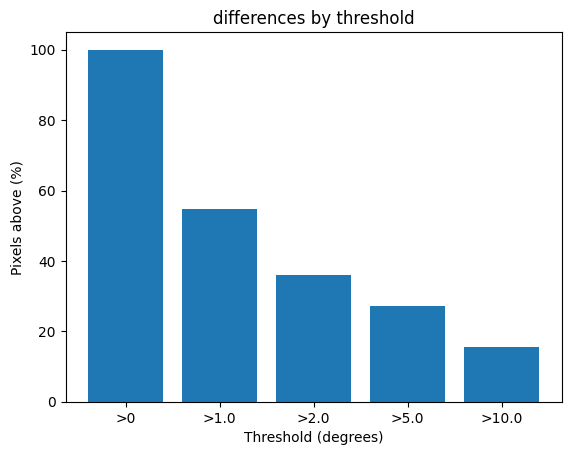

In [ ]:
# Plot bar chart with threshold labels
thresholds = [0,1.0, 2.0, 5.0, 10.0]
fractions = [float(np.mean(np.abs(d) > thr)) * 100 for thr in thresholds]

plt.figure()
plt.title("differences by threshold")

bars = plt.bar(range(len(thresholds)), fractions) # Create bars

plt.xlabel("Threshold (degrees)")
plt.ylabel("Pixels above (%)")
plt.xticks(range(len(thresholds)), [f">{t}" for t in thresholds])
plt.show()


#### model trained with HR data applied with HR data - model trained with global applied with global datasets

In [ ]:
os.makedirs(os.path.dirname(out_diff), exist_ok=True)

with rasterio.open(mrt_predicted_hr_data) as src1, \
     rasterio.open(mrt_predicted_global_data_2) as src2:

    # determine common intersection
    h = min(src1.height, src2.height)
    w = min(src1.width, src2.width)

    # read only that intersection (light)
    r1 = src1.read(1, window=((0, h), (0, w))).astype("float32")
    r2 = src2.read(1, window=((0, h), (0, w))).astype("float32")

    nodata = src1.nodata

    # build mask in HR intersection grid
    mask = np.isfinite(r1)
    if nodata is not None:
        mask &= (r1 != nodata)

    diff = r1 - r2
    diff[~mask] = nodata

    profile = src1.profile
    profile.update(dtype="float32", height=h, width=w, transform=src1.transform)

    with rasterio.open(out_diff, "w", **profile) as dst:
        dst.write(diff.astype("float32"), 1)

    print("Saved in:", out_diff)

Saved in: ../../datos-notebooks/4.comparative-analysis/MRT_difference_bologna.tif


In [ ]:
# Quantify raster differences
with rasterio.open(out_diff) as srcd:
    diff = srcd.read(1).astype("float32")
    nodata = srcd.nodata

# Build valid mask
mask = np.isfinite(diff)
if nodata is not None:
    mask &= (diff != nodata)

d = diff[mask]

# Basic stats 
print(f"Mean diff: {np.mean(d):.3f}")
print(f"Median diff: {np.median(d):.3f}")
print(f"Std diff: {np.std(d):.3f}")

# Error-like metrics 
mae = float(np.mean(np.abs(d)))
rmse = float(np.sqrt(np.mean(d**2)))
print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")

Mean diff: -1.420
Median diff: -0.146
Std diff: 5.005
MAE: 3.047
RMSE: 5.203


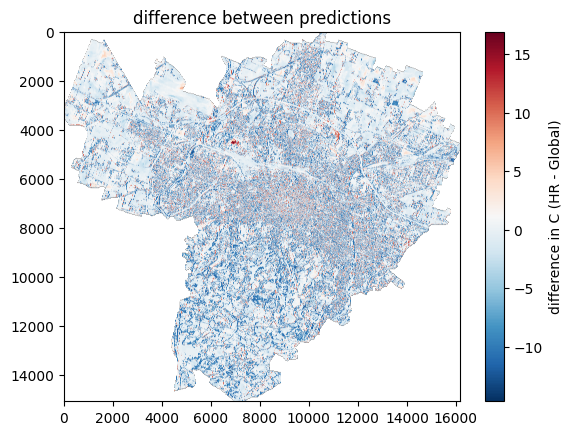

In [ ]:
# Plot result 
with rasterio.open(out_diff) as src:
    xmin, ymin, xmax, ymax = src.bounds

plt.figure()
plt.title("difference between predictions")
plt.imshow(diff, cmap='RdBu_r')
plt.colorbar(label="difference in C (HR - Global)")
plt.show()

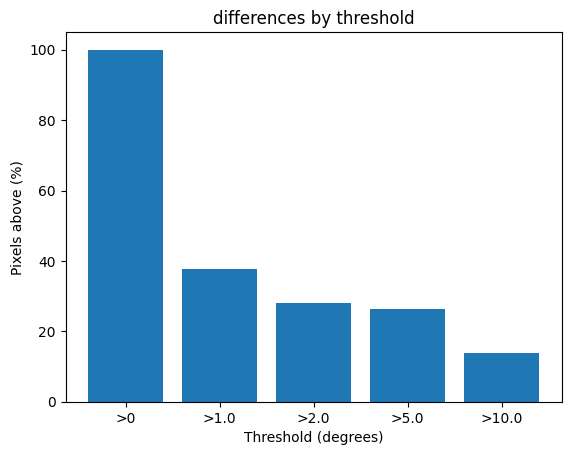

In [ ]:
# Plot bar chart with threshold labels
thresholds = [0,1.0, 2.0, 5.0, 10.0]
fractions = [float(np.mean(np.abs(d) > thr)) * 100 for thr in thresholds]

plt.figure()
plt.title("differences by threshold")

bars = plt.bar(range(len(thresholds)), fractions) # Create bars

plt.xlabel("Threshold (degrees)")
plt.ylabel("Pixels above (%)")
plt.xticks(range(len(thresholds)), [f">{t}" for t in thresholds])
plt.show()